# Importing Required Libraries

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder


# Loading the Dataset

In [102]:
data= pd.read_csv("Student Depression Dataset.csv")
data = data.dropna()
data.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


# Dropping the Irrelevant Columns

In [103]:
data.drop(['id', 'City', 'Profession'], axis=1, inplace=True)



# Encoding

In [104]:
encoder = LabelEncoder()
data["Gender"]= encoder.fit_transform(data["Gender"])
data["Sleep Duration"]= encoder.fit_transform(data["Sleep Duration"])
data["Dietary Habits"]= encoder.fit_transform(data["Dietary Habits"])
data["Degree"]= encoder.fit_transform(data["Degree"])
data["Have you ever had suicidal thoughts ?"]= encoder.fit_transform(data["Have you ever had suicidal thoughts ?"])
data["Family History of Mental Illness"]= encoder.fit_transform(data["Family History of Mental Illness"])



# Splitting into Target 

In [105]:
X = data.drop('Depression', axis=1)
y = data['Depression']

# Splitting for Training and Testing

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Loading the Model

In [107]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

# Predictions

In [108]:
predictions= model.predict(X_test)
accuracy = accuracy_score(y_test , predictions)
print(f" Accuracy is {accuracy}")

 Accuracy is 0.8440860215053764


# Graph

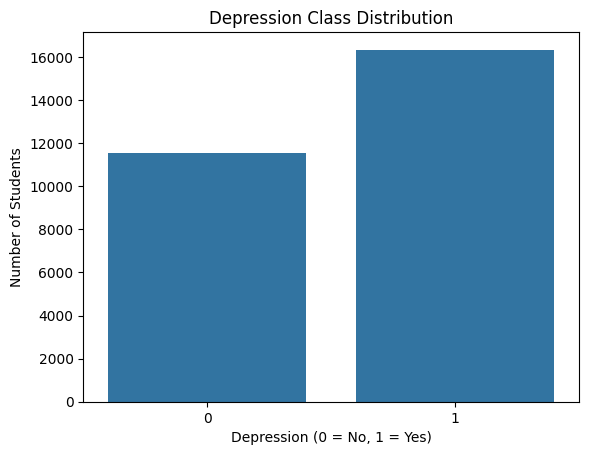

In [109]:
#GRaph
sns.countplot(x='Depression', data=data)
plt.title("Depression Class Distribution")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()